<details><summary style="display:list-item; font-size:16px; color:blue;">Jupyter Help</summary>
    
Having trouble testing your work? Double-check that you have followed the steps below to write, run, save, and test your code!
    
[Click here for a walkthrough GIF of the steps below](https://static-assets.codecademy.com/Courses/ds-python/jupyter-help.gif)

Run all initial cells to import libraries and datasets. Then follow these steps for each question:
    
1. Add your solution to the cell with `## YOUR SOLUTION HERE ## `.
2. Run the cell by selecting the `Run` button or the `Shift`+`Enter` keys.
3. Save your work by selecting the `Save` button, the `command`+`s` keys (Mac), or `control`+`s` keys (Windows).
4. Select the `Test Work` button at the bottom left to test your work.

![Screenshot of the buttons at the top of a Jupyter Notebook. The Run and Save buttons are highlighted](https://static-assets.codecademy.com/Paths/ds-python/jupyter-buttons.png)

**Setup**
Run the following cell to import libraries and helper function.

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

#### Checkpoint 1/2

Create an autoencoder class with **convolution-based** hidden layers (instead of linear layers) to better learn hidden visual representations within the MNIST images. 

**A.** Create a class named `ConvAutoencoder` initialized with two components: 
- `self.encoder`: The encoder compresses the input image into a 32D latent space.
- `self.decoder`: The decoder that reconstructs the input image from the 32D latent space.

**B.** Build the encoder using `nn.Sequential` with components in the following order:

1. A first convolution layer (`Conv2d`) that inputs 1 channel, outputs 16 feature maps, where each filter is a 3x3 window that moves at a stride of 2 pixels at a time, and pads with a 1 pixel border. 

2. A **ReLU** activation function.

3. A second convolution layer that inputs the 16 feature maps, outputs 32 feature maps using the same window size, stride, and padding as the first convolution layer. This should output the latent representation. 

**C.** Build the decoder using `nn.Sequential` with components in the following order: 

1. A reverse convolution layer (`ConvTranspose2d`) that inputs the latent representation with 32 channels, outputs 16 feature maps, using the same window size, stride, and padding as the previous `Conv2d` layers, but additionally 1 pixel of output padding (`output_padding=`).

2. A **ReLU** activation function.

3. A second reverse convolution layer that inputs the 16 feature maps, outputs a single channel (same as the original MNIST input), same window size, stride, padding, and output padding as the previous reverse layer.

4. Lastly, a **Sigmoid** activation function.

**D.** Build the forward pass that uses the encoder that processes the input image into the latent representation, and the decoder that reconstructs the image from the latent representation. The forward pass should return the reconstructed image.

Don't forget to run the cell and save the notebook before selecting `Test Work`! Open the `Jupyter Help` toggle at the top of the notebook for more details.

In [2]:
import torch
import torch.nn as nn

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),   # (1,28,28) → (16,14,14)
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # (16,14,14) → (32,7,7)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),  # → (16,14,14)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),   # → (1,28,28)
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_x = self.encoder(x)
        recon_x = self.decoder(latent_x)
        return recon_x

conv_autoencoder = ConvAutoencoder()

**Note:** We've instantiated the model and pretrained weights to the variable `conv_autoencoder`. If the architecture does not exactly match the correct architecture, PyTorch will return a **mismatch error**.

#### Checkpoint 2/2

We've loaded the MNIST testing set in batches to the variables `test_data` and `test_loader`. 

Input each image through the autoencoder to generate latent representations from the encoder that are reconstructed by the decoder.

**A.** Set the autoencoder to evaluation mode.

**B.** Initialize an empty list named `batch_recons` that will contain all of the reconstructed testing images.

**C.** Within `with torch.no_grad()`, loop through the testing set batches and pass them through the autoencoder to get the reconstructed outputs. Assign each batch of reconstructed images within the loop to the variable `recon_x`, and add each batch to `batched_recons`.

**D.** Concatenate every batch together into a single tensor along the same dimension. Save the tensor to the variable `all_recons`.

Don't forget to run the cell and save the notebook before selecting `Test Work`! Open the `Jupyter Help` toggle at the top of the notebook for more details.

In [3]:
conv_autoencoder.eval()
test_data = datasets.MNIST(root="./datasets", 
                           train=False, 
                           download=True, 
                           transform=transforms.ToTensor())

test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

## YOUR SOLUTION HERE ##

batched_recons = []

with torch.no_grad():
    for x, _ in test_loader:
        recon_x = conv_autoencoder(x)
        batched_recons.append(recon_x)
all_recons = torch.cat(batched_recons, dim=0)

The following cell that selects the first image from the current batch at `idx=0` and displays the original and reconstructed version side-by-side using `matplotlib`.

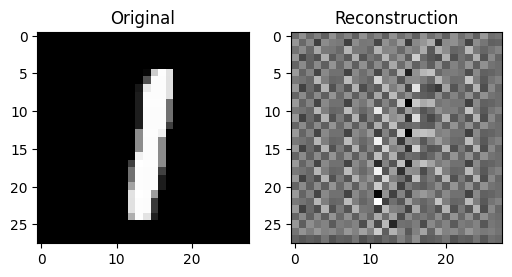

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

# Select first image in the current batch
idx = 0
original = x[idx, 0]
reconstruction = recon_x[idx, 0]

# Show output - visualize reconstructed image
def show_reconstruction(original, reconstruction):
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap="gray")
    plt.title("Original")

    plt.subplot(1, 2, 2)
    plt.imshow(reconstruction, cmap="gray")
    plt.title("Reconstruction")
    plt.show()

show_reconstruction(original, reconstruction)